In [1]:
import re
import datetime
import pathlib
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
VERSION = datetime.datetime.now().strftime("%y%m%d")
print(f"Execute Date: {VERSION}")

Execute Date: 260324


## Parameters for papermill

In [3]:
foldseek_result_tsv = pathlib.Path("../test/oryza_sativa_test_100genes_202603/foldseek_output_human_proteome_v6_os_100_genes_9606.tsv")
query_uniprot_idmapping_tsv = pathlib.Path("../test/oryza_sativa_test_100genes_202603/os_100_genes_idmapping_all.tsv")
water_result_dir_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/result_water")
needle_result_dir_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/result_needle")
query_gene_list_tsv_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/oryza_sativa_random_100genes_list.tsv")
togoid_convert_tsv_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/foldseek_target_species_togoid_convert.tsv")

In [4]:
# Parameters
foldseek_result_tsv = "/tmp/lt0xahyq/stg2fb56718-081c-44ff-b11d-77d47a04527c/foldseek_os_random_9606.tsv"
query_uniprot_idmapping_tsv = "/tmp/lt0xahyq/stg2b784a9b-7f82-4992-9925-8c4c55fcdf68/zm_100_genes_idmapping_all.tsv"
water_result_dir_path = "/tmp/lt0xahyq/stg0fb144a3-b7f1-44b4-8176-7b541e9d23fd/result_water"
needle_result_dir_path = "/tmp/lt0xahyq/stg75b524c2-04d8-47ef-acc7-9149dba573ce/result_needle"
query_gene_list_tsv_path = "/tmp/lt0xahyq/stg18004ce0-a47e-4e9f-8778-8ce787392caf/zea_mays_random_100genes_list.tsv"
togoid_convert_tsv_path = "/tmp/lt0xahyq/stg2a4b95e0-b1db-4064-9374-3bf6b683128e/foldseek_hit_species_togoid_convert.tsv"


&nbsp;

&nbsp;

&nbsp;

## (1) Foldseek (Structural Alignment) Result

- Foldseek version: [10-941cd33](https://github.com/steineggerlab/foldseek/releases/tag/10-941cd33)
- About Column name: [foldseek GitHub page](https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search)
- In this workflow, foldseek alignment type is `TM-align` (default). So, `e-value` column means `(qTMscore+tTMscore) / 2`
- More details: [TM-align Alignment mode](https://github.com/steineggerlab/foldseek?tab=readme-ov-file#alignment-mode)

&nbsp;

### About Hit Pairs

- In this analysis workflow, the results are output with multiple hits remaining for a single query UniProt ID (protein structure).

&nbsp;

In [5]:
foldseek_result_df = pl.read_csv(
    foldseek_result_tsv,
    separator='\t'
).with_columns(
    (pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession")), # "?" means non-greedy
    (pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit"))
)

foldseek_result = pl.read_csv(
    query_uniprot_idmapping_tsv, # query idmapping
    separator='\t'
).join(
    foldseek_result_df,
    on="UniProt Accession",
    how="inner",
    coalesce=True
)

display(foldseek_result)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str
"""Zm00001eb409230""","""A0A804RDG3""","""Q04446""",0.4525,0.411,50,3.4,0.034,28,2,587,587,109,699,702,823,0.998,0.842,0.4372,0.5013,0.427,0.5028,4.721,"""DCR-R-------------------------…","""PFSYPYKKLDYGKWELYIPPKQNKSVLVPH…",326,"""0.500,0.643,0.375,0.389,0.250,…"
"""Zm00001eb409230""","""A0A804RDG3""","""Q07837""",0.426,0.326,51,3.7,0.037,26,17,587,587,168,652,685,716,0.973,0.708,0.3805,0.4682,0.4086,0.5538,5.081,"""REVTPTWISDSYGFDNIDEWGRPFPDLQRF…","""SSLKDFR-----YGVED-----FREVDPIF…",314,"""0.214,0.258,0.303,0.306,0.260,…"
"""Zm00001eb409230""","""A0A804RDG3""","""Q8WVB3""",0.3727,0.126,28,3.7,0.037,14,18,320,587,16,329,486,375,0.516,0.646,0.4018,0.351,0.4151,0.6287,4.234,"""EVTPT-------------------------…","""LKGAPPKVSYLSEIFPLFRALGANGLLIEY…",228,"""0.136,0.184,0.311,0.250,0.194,…"
"""Zm00001eb409230""","""A0A804RDG3""","""P43251""",0.322,0.098,49,1.8,0.018,15,14,582,587,10,536,543,819,0.969,0.971,0.2828,0.3278,0.3488,0.3574,7.002,"""DHD---------------------------…","""RRAKSRFVVCIMSGARSKLALFLCGCYVVA…",262,"""0.100,0.125,0.103,0.178,0.117,…"
"""Zm00001eb409230""","""A0A804RDG3""","""P11413""",0.2897,0.069,40,2.5,0.025,20,45,577,587,13,504,515,784,0.908,0.955,0.279,0.2884,0.3197,0.3319,6.96,"""RF------PSSRVDRGFSQIASKVHG-MGL…","""CGILREEL----------FQGDAFHQS---…",221,"""0.051,0.138,0.205,0.101,0.116,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zm00001eb394270""","""A0A1D6P9G6""","""O75570""",0.1819,0.016,32,1.8,0.018,13,34,472,504,17,428,445,709,0.871,0.926,0.3012,0.1838,0.2024,0.2137,7.315,"""TYKNGSNGI--------------VIKLADG…","""GYLQCHIQLHSHQFRQIHLDTRL-------…",129,"""0.211,0.278,0.309,0.393,0.458,…"
"""Zm00001eb394270""","""A0A1D6P9G6""","""Q86VW2""",0.1813,0.024,38,1.8,0.018,12,16,499,504,102,409,580,647,0.96,0.531,0.3478,0.2,0.1788,0.2906,6.951,"""ALRP--------------------------…","""PYENWMLEPALATGEELPELTLLTTLLEGP…",133,"""0.306,0.375,0.275,0.333,0.100,…"
"""Zm00001eb394270""","""A0A1D6P9G6""","""Q9BZ67""",0.1778,0.016,36,1.1,0.011,7,1,501,504,187,456,464,626,0.994,0.582,0.2845,0.1832,0.1948,0.2799,7.65,"""MTKA--------------------------…","""RPAACDLREKLDSFLPAHLCKRGQSLFAAL…",138,"""0.500,0.550,0.583,0.607,0.281,…"


&nbsp;

&nbsp;

## (2) Create Scatter Plot for all hits (Strucutural alignment identity vs LDDT)

- Identity in the results of the structural alignment is also output in the foldseek output.
- However, in this notebook, you can also select the results of the pairwise alignment of amino acid sequences (global alignment, local alignment).

&nbsp;

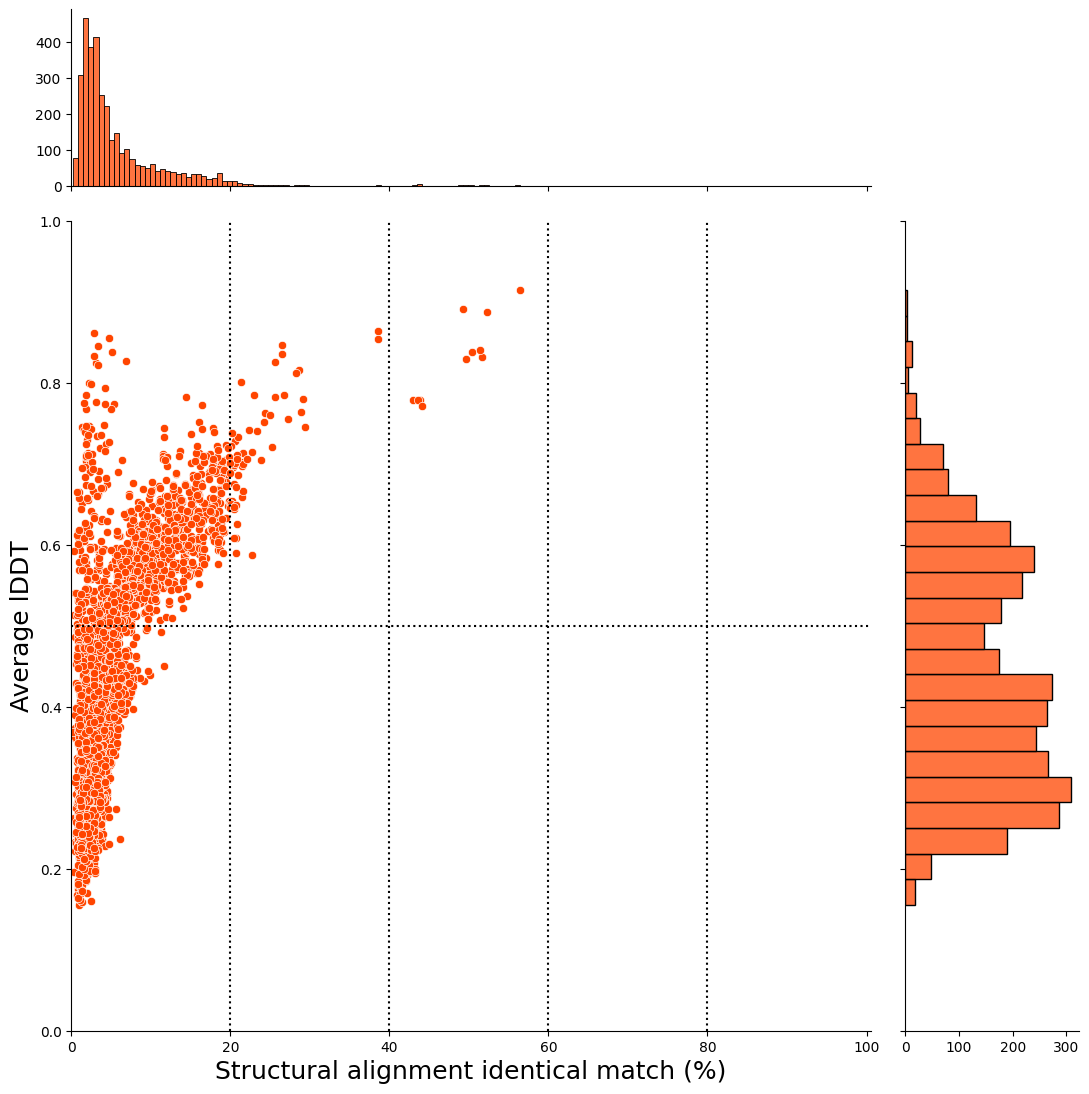

In [6]:
foldseek_filter_viz = foldseek_result.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz,
    x="pident", # structural alignment identical match from foldseek result
    y="lddt",
    color="orangered",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(0,100.5)
plt.ylim(0,1)
plt.xlabel("Structural alignment identical match (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

# Save as PNG
plt.savefig(
    "foldseek_result_pident_lddt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (3) Parse protein sequence pairwise alignment result (water and needle)

- package: EMBOSS:6.5.7--4
- Score Subsutitution Matrix: EBLOSUM30 (For considering remote similarity)
- Website: [EMBOSS](https://emboss.sourceforge.net/)
- needle document: [EMBOSS needle](https://emboss.sourceforge.net/apps/release/6.0/emboss/apps/needle.html)
- water document: [EMBOSS water](https://emboss.sourceforge.net/apps/cvs/emboss/apps/water.html)
- EMBL-EBI Webserver: [EMBOSS NEEDLE](https://www.ebi.ac.uk/jdispatcher/psa/emboss_needle)
- EMBL-EBI Webserver: [EMBOSS WATER](https://www.ebi.ac.uk/jdispatcher/psa/emboss_water)

- For pairs hit by Foldseek (structural alignment), we perform analysis on the sequence similarity observed upon alignment at the `protein sequence level`.
- In other words, it is performing an alignment again on the pair of sequences, not just the regions aligned by Foldseek.

&nbsp;

In [7]:
def parse_needle_water_result(file_path: str | pathlib.Path) -> dict:
    with open(file_path, "r", encoding="utf-8") as file:
        data = file.readlines()

    result = {
        "UniProt Accession": None,
        "foldseek hit": None,
        "Matrix": None,
        "Gap_penalty": None,
        "Extend_penalty": None,
        "Align_Length": None,
        "Identity": None,
        "Identity_percent": None,
        "Similarity": None,
        "Similarity_percent": None,
        "Gaps": None,
        "Gaps_percent": None,
        "Score": None,
        "Longest_Identity": None,
        "Longest_Similarity": None,
        "Shortest_Identity": None,
        "Shortest_Similarity": None,
    }

    for line in data:
        if line.startswith("# 1:"):
            result['UniProt Accession'] = line.split(":")[1].strip()
        elif line.startswith("# 2:"):
            result["foldseek hit"] = line.split(":")[1].strip()
        elif line.startswith("# Matrix:"):
            result["Matrix"] = line.split(":")[1].strip()
        elif line.startswith("# Gap_penalty:"):
            result["Gap_penalty"] = float(line.split(":")[1].strip())
        elif line.startswith("# Extend_penalty:"):
            result["Extend_penalty"] = float(line.split(":")[1].strip())
        elif line.startswith("# Length:"):
            result["Align_Length"] = int(line.split()[2])
        elif line.startswith("# Identity:"):
            result["Identity"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Identity_percent"] = float(m.group(1))
        elif line.startswith("# Similarity:"):
            result["Similarity"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Similarity_percent"] = float(m.group(1))
        elif line.startswith("# Gaps:"):
            result["Gaps"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Gaps_percent"] = float(m.group(1))
        elif line.startswith("# Score:"):
            result["Score"] = float(line.split()[2])
        elif line.startswith("# Longest_Identity"):
            result["Longest_Identity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Longest_Similarity"):
            result["Longest_Similarity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Shortest_Identity"):
            result["Shortest_Identity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Shortest_Similarity"):
            result["Shortest_Similarity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )

    return result

In [8]:
water_result_dir = pathlib.Path(water_result_dir_path)
needle_result_dir = pathlib.Path(needle_result_dir_path)

# Initialize empty lists to store DataFrames
water_dfs = []
needle_dfs = []

# Collect all water results
for result_file in water_result_dir.glob("*_align.water"):
    parsed_data = parse_needle_water_result(result_file)
    water_dfs.append(pl.DataFrame([parsed_data]))

# Collect all needle results    
for result_file in needle_result_dir.glob("*_align.needle"):
    parsed_data = parse_needle_water_result(result_file)
    needle_dfs.append(pl.DataFrame([parsed_data]))

# Combine all results and sort only if there are results
water_result = (pl.concat(water_dfs, how='vertical')
                .sort(["UniProt Accession", "foldseek hit"]) 
                if water_dfs else pl.DataFrame()).with_columns(
                    pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession"), # add removing AF- prefix
                    pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit") # add removing AF- prefix
                )

needle_result = (pl.concat(needle_dfs, how='vertical')
                 .sort(["UniProt Accession", "foldseek hit"])
                 if needle_dfs else pl.DataFrame()).with_columns(
                    pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession"), # add removing AF- prefix
                    pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit") # add removing AF- prefix
                )

display(water_result)
display(needle_result)

UniProt Accession,foldseek hit,Matrix,Gap_penalty,Extend_penalty,Align_Length,Identity,Identity_percent,Similarity,Similarity_percent,Gaps,Gaps_percent,Score,Longest_Identity,Longest_Similarity,Shortest_Identity,Shortest_Similarity
str,str,str,f64,f64,i64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64
"""A0A096RP22""","""A0A494C086""","""EBLOSUM30""",10.0,0.5,426,"""85/426""",20.0,"""158/426""",37.1,"""93/426""",21.8,249.0,25.53,47.45,21.14,39.3
"""A0A096RP22""","""A6NP11""","""EBLOSUM30""",10.0,0.5,384,"""71/384""",18.5,"""140/384""",36.5,"""103/384""",26.8,174.5,25.27,49.82,14.34,28.28
"""A0A096RP22""","""O43711""","""EBLOSUM30""",10.0,0.5,380,"""64/380""",16.8,"""125/380""",32.9,"""156/380""",41.1,227.5,28.57,55.8,16.98,33.16
"""A0A096RP22""","""O43763""","""EBLOSUM30""",10.0,0.5,388,"""70/388""",18.0,"""125/388""",32.2,"""145/388""",37.4,211.5,28.81,51.44,18.57,33.16
"""A0A096RP22""","""P05412""","""EBLOSUM30""",10.0,0.5,352,"""74/352""",21.0,"""143/352""",40.6,"""95/352""",27.0,233.5,28.79,55.64,19.63,37.93
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P12857""","""Q9UPY5""","""EBLOSUM30""",10.0,0.5,454,"""92/454""",20.3,"""160/454""",35.2,"""148/454""",32.6,275.5,30.07,52.29,18.36,31.94
"""P12857""","""Q9Y548""","""EBLOSUM30""",10.0,0.5,339,"""64/339""",18.9,"""123/339""",36.3,"""108/339""",31.9,209.5,27.71,53.25,16.54,31.78
"""P12857""","""Q9Y619""","""EBLOSUM30""",10.0,0.5,332,"""68/332""",20.5,"""152/332""",45.8,"""63/332""",19.0,365.0,25.28,56.51,17.57,39.28


UniProt Accession,foldseek hit,Matrix,Gap_penalty,Extend_penalty,Align_Length,Identity,Identity_percent,Similarity,Similarity_percent,Gaps,Gaps_percent,Score,Longest_Identity,Longest_Similarity,Shortest_Identity,Shortest_Similarity
str,str,str,f64,f64,i64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64
"""A0A096RP22""","""A0A494C086""","""EBLOSUM30""",10.0,0.5,440,"""85/440""",19.3,"""159/440""",36.1,"""101/440""",23.0,242.0,25.07,46.9,21.14,39.55
"""A0A096RP22""","""A6NP11""","""EBLOSUM30""",10.0,0.5,593,"""81/593""",13.7,"""142/593""",23.9,"""314/593""",53.0,172.0,29.03,50.9,16.36,28.69
"""A0A096RP22""","""O43711""","""EBLOSUM30""",10.0,0.5,439,"""66/439""",15.0,"""128/439""",29.2,"""210/439""",47.8,224.5,28.82,55.9,17.51,33.95
"""A0A096RP22""","""O43763""","""EBLOSUM30""",10.0,0.5,411,"""70/411""",17.0,"""125/411""",30.4,"""161/411""",39.2,208.5,28.0,50.0,18.57,33.16
"""A0A096RP22""","""P05412""","""EBLOSUM30""",10.0,0.5,449,"""74/449""",16.5,"""143/449""",31.8,"""190/449""",42.3,229.5,28.57,55.21,19.63,37.93
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P12857""","""Q9UPY5""","""EBLOSUM30""",10.0,0.5,566,"""93/566""",16.4,"""163/566""",28.8,"""244/566""",43.1,272.0,28.88,50.62,18.56,32.53
"""P12857""","""Q9Y548""","""EBLOSUM30""",10.0,0.5,451,"""65/451""",14.4,"""127/451""",28.2,"""209/451""",46.3,200.0,26.86,52.48,16.8,32.82
"""P12857""","""Q9Y619""","""EBLOSUM30""",10.0,0.5,413,"""68/413""",16.5,"""153/413""",37.0,"""138/413""",33.4,362.0,24.73,55.64,17.57,39.53


In [9]:
alignment_result = water_result.join(
    needle_result,
    on=["UniProt Accession", "foldseek hit"],
    how="inner",
    coalesce=True,
    suffix="_needle"
).rename(
    {
        "Align_Length": "Align_Length_water",
        "Identity": "Identity_water",
        "Identity_percent": "Identity_percent_water",
        "Similarity": "Similarity_water",
        "Similarity_percent": "Similarity_percent_water",
        "Gaps": "Gaps_water",
        "Gaps_percent": "Gaps_percent_water",
        "Longest_Identity": "Longest_Identity_water",
        "Longest_Similarity": "Longest_Similarity_water",
        "Shortest_Identity": "Shortest_Identity_water",
        "Shortest_Similarity": "Shortest_Similarity_water",
        "Score": "Score_water"
    }
).select(
    [
        "UniProt Accession",
        "foldseek hit",
        "Align_Length_water",
        "Align_Length_needle",
        "Identity_water",
        "Identity_needle",
        "Identity_percent_water",
        "Identity_percent_needle",
        "Similarity_percent_water",
        "Similarity_percent_needle",
        "Gaps_water",
        "Gaps_needle",
        "Gaps_percent_water",
        "Gaps_percent_needle",
        "Shortest_Identity_water",
        "Shortest_Identity_needle",
        "Longest_Identity_water",
        "Longest_Identity_needle",
        "Shortest_Similarity_water",
        "Shortest_Similarity_needle",
        "Longest_Similarity_water",
        "Longest_Similarity_needle",
        "Score_water",
        "Score_needle",
        "Gap_penalty",
        "Extend_penalty",
        "Matrix"
    ]
)

display(alignment_result)

UniProt Accession,foldseek hit,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""A0A096RP22""","""A0A494C086""",426,440,"""85/426""","""85/440""",20.0,19.3,37.1,36.1,"""93/426""","""101/440""",21.8,23.0,21.14,21.14,25.53,25.07,39.3,39.55,47.45,46.9,249.0,242.0,10.0,0.5,"""EBLOSUM30"""
"""A0A096RP22""","""A6NP11""",384,593,"""71/384""","""81/593""",18.5,13.7,36.5,23.9,"""103/384""","""314/593""",26.8,53.0,14.34,16.36,25.27,29.03,28.28,28.69,49.82,50.9,174.5,172.0,10.0,0.5,"""EBLOSUM30"""
"""A0A096RP22""","""O43711""",380,439,"""64/380""","""66/439""",16.8,15.0,32.9,29.2,"""156/380""","""210/439""",41.1,47.8,16.98,17.51,28.57,28.82,33.16,33.95,55.8,55.9,227.5,224.5,10.0,0.5,"""EBLOSUM30"""
"""A0A096RP22""","""O43763""",388,411,"""70/388""","""70/411""",18.0,17.0,32.2,30.4,"""145/388""","""161/411""",37.4,39.2,18.57,18.57,28.81,28.0,33.16,33.16,51.44,50.0,211.5,208.5,10.0,0.5,"""EBLOSUM30"""
"""A0A096RP22""","""P05412""",352,449,"""74/352""","""74/449""",21.0,16.5,40.6,31.8,"""95/352""","""190/449""",27.0,42.3,19.63,19.63,28.79,28.57,37.93,37.93,55.64,55.21,233.5,229.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P12857""","""Q9UPY5""",454,566,"""92/454""","""93/566""",20.3,16.4,35.2,28.8,"""148/454""","""244/566""",32.6,43.1,18.36,18.56,30.07,28.88,31.94,32.53,52.29,50.62,275.5,272.0,10.0,0.5,"""EBLOSUM30"""
"""P12857""","""Q9Y548""",339,451,"""64/339""","""65/451""",18.9,14.4,36.3,28.2,"""108/339""","""209/451""",31.9,46.3,16.54,16.8,27.71,26.86,31.78,32.82,53.25,52.48,209.5,200.0,10.0,0.5,"""EBLOSUM30"""
"""P12857""","""Q9Y619""",332,413,"""68/332""","""68/413""",20.5,16.5,45.8,37.0,"""63/332""","""138/413""",19.0,33.4,17.57,17.57,25.28,24.73,39.28,39.53,56.51,55.64,365.0,362.0,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (4) Integrate foldseek result and pairwise alignment result

- This time, **exclude the ones that are null in pairwise alignment result, which means the current UniProt entry is obsolete**

In [10]:
join_foldseek = foldseek_result.join(
    alignment_result,
    on=["UniProt Accession", "foldseek hit"],
    how="left",
    coalesce=True
).filter( # filter out null alignment result (this means current UniProt entry is obsolete)
    pl.col("Align_Length_water").is_not_null() & 
    pl.col("Align_Length_needle").is_not_null()
).unique()

join_foldseek.write_csv(
    "foldseek_result_join_alignment_result_all.tsv",
    separator='\t'
)


display(join_foldseek)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""Zm00001eb371600""","""A0A804QZN7""","""Q9BT22""",0.2251,0.045,35,2.0,0.02,12,72,390,397,29,451,464,577,0.804,0.912,0.2726,0.2547,0.2268,0.2953,7.325,"""HLSITVPRVLFVAE----------------…","""GRAARHVVAVVLGDVGRSPRMQYHALSLAM…",153,"""0.278,0.339,0.475,0.500,0.353,…",508,555,"""92/508""","""93/555""",18.1,16.8,33.3,31.2,"""214/508""","""249/555""",42.1,44.9,19.83,20.04,31.29,30.39,36.42,37.28,57.48,56.54,315.0,309.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb189380""","""P12857""","""Q9UNW8""",0.2114,0.034,28,1.3,0.013,6,89,379,387,47,328,380,436,0.752,0.742,0.357,0.2236,0.2266,0.2761,7.058,"""I-DFMMGGVSAAVSKTAAAPIE--------…","""VV-YSAVCTLGVPANCLTAWLALLQVLQGN…",131,"""0.287,0.238,0.295,0.302,0.291,…",424,508,"""77/424""","""81/508""",18.2,15.9,34.9,31.1,"""180/424""","""249/508""",42.5,49.0,19.9,20.93,31.56,31.27,38.24,40.83,60.66,61.0,239.5,238.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb116750""","""C0HI29""","""Q8N9V3""",0.3884,0.214,32,5.0,0.05,21,68,422,429,1,294,476,413,0.828,0.618,0.36,0.4226,0.3869,0.578,5.067,"""SRPSKGPAISGKFDYLPSAGQVIDHCNG-L…","""MVK----LIHTLAD-H-GDDVNCCAFSFSL…",215,"""0.080,0.209,0.155,0.157,0.182,…",551,564,"""96/551""","""96/564""",17.4,17.0,33.0,32.3,"""213/551""","""223/564""",38.7,39.5,20.17,20.17,28.4,28.15,38.24,38.24,53.85,53.37,338.5,334.5,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb272780""","""A0A804UAK0""","""Q9HCJ2""",0.379,0.126,39,4.5,0.045,41,23,739,776,24,570,640,919,0.924,0.855,0.4388,0.3572,0.423,0.4843,5.957,"""LLLLLLTLTLARPAAAQPPT----SPALQA…","""DPLLVVLLALQLLVVAGLVRAQTC------…",304,"""0.485,0.588,0.588,0.618,0.641,…",831,858,"""163/831""","""166/858""",19.6,19.3,34.1,33.4,"""282/831""","""300/858""",33.9,35.0,21.01,21.39,29.69,29.75,36.47,36.98,51.55,51.43,559.5,551.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb305300""","""C4J4G8""","""Q06418""",0.3362,0.164,25,18.1,0.181,63,307,637,683,479,789,890,348,0.485,0.349,0.6115,0.3829,0.2984,0.7922,4.191,"""LAVGSAAFLLVRRHLKYAELR-E-D-WELE…","""AARSFN-RERPERIEATLDSLGISDELKEK…",231,"""0.092,0.125,0.171,0.158,0.175,…",885,958,"""187/885""","""188/958""",21.1,19.6,38.9,36.2,"""273/885""","""343/958""",30.8,35.8,21.01,21.12,30.56,30.57,38.65,38.99,56.21,56.42,686.0,683.0,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zm00001eb046650""","""A0A1D6KU13""","""O95786""",0.3922,0.138,56,4.4,0.044,49,68,1024,1112,143,779,925,1124,0.861,0.689,0.4919,0.3656,0.4326,0.603,5.466,"""ED--DD--NE--K---R------LKTVI--…","""CSTKGMMAGAEKLVECLLRSDKENWPKTLK…",421,"""0.125,0.344,0.438,0.562,0.469,…",1169,1257,"""215/1169""","""211/1257""",18.4,16.8,37.5,34.0,"""380/1169""","""477/1257""",32.5,37.9,19.33,18.97,27.25,27.05,39.39,38.4,55.51,54.74,692.0,692.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb074030""","""A0A1D6E3A9""","""O43868""",0.2034,0.04,31,2.2,0.022,13,102,430,527,165,615,658,611,0.624,0.685,0.2265,0.2316,0.1923,0.3343,6.405,"""NAYYAAFHNLSSGIGFQALVLPTAFASLGW…","""LDTAQRPEQLIPFAGICMFILILFACSKHH…",156,"""0.191,0.221,0.185,0.187,0.130,…",692,753,"""133/692""","""124/753""",19.2,16.5,36.3,33.6,"""272/692""","""321/753""",39.3,42.6,

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (5) Create Scatter Plot for all hits (x-axis: Similarity_percent_needle) Global alignment

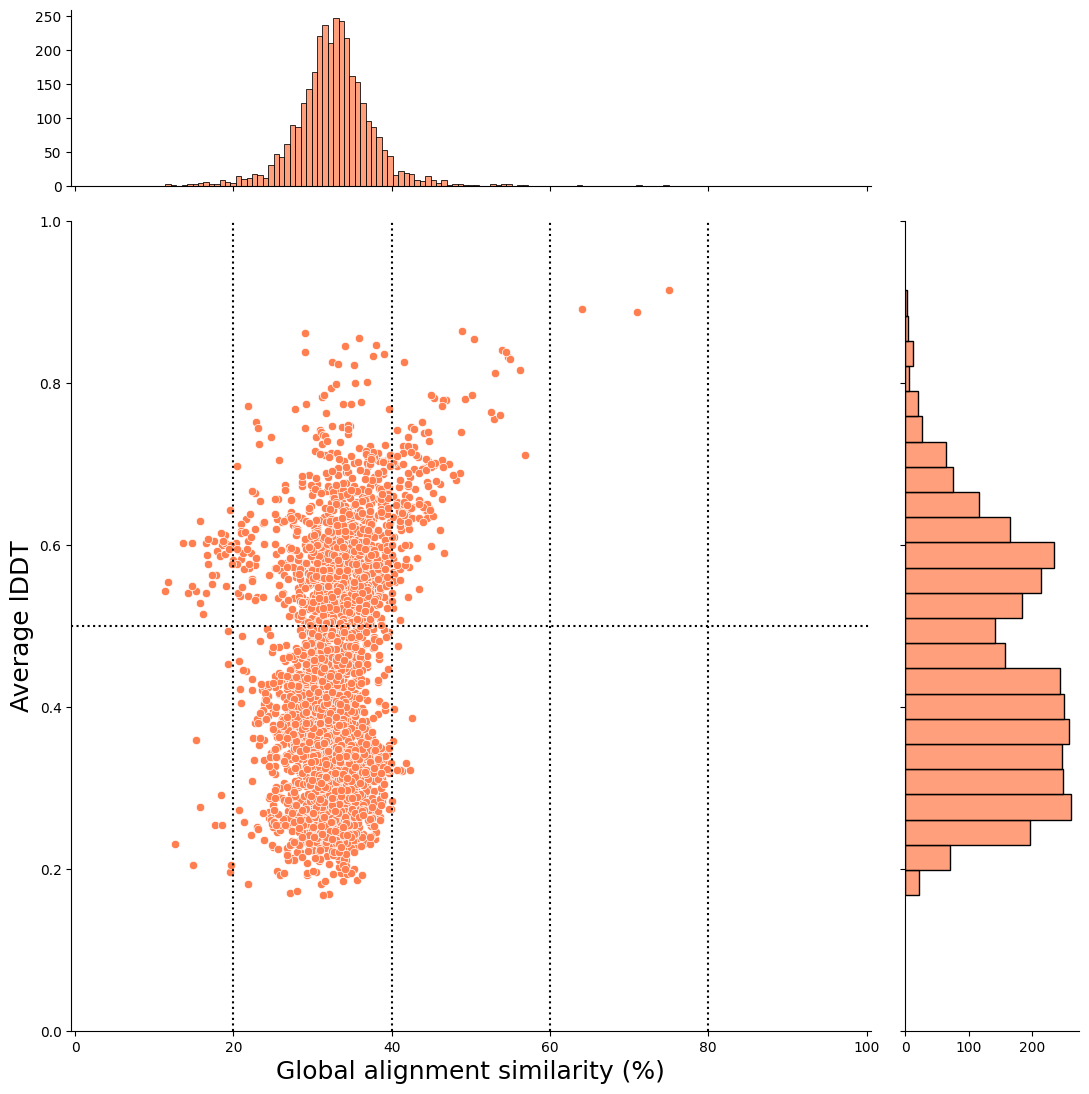

In [11]:
foldseek_filter_viz2 = join_foldseek.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz2,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100.5)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_needle_lddt_all.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## Create Scatter Plot for all hits (x-axis: Similarity_percent_water) Local Alignment

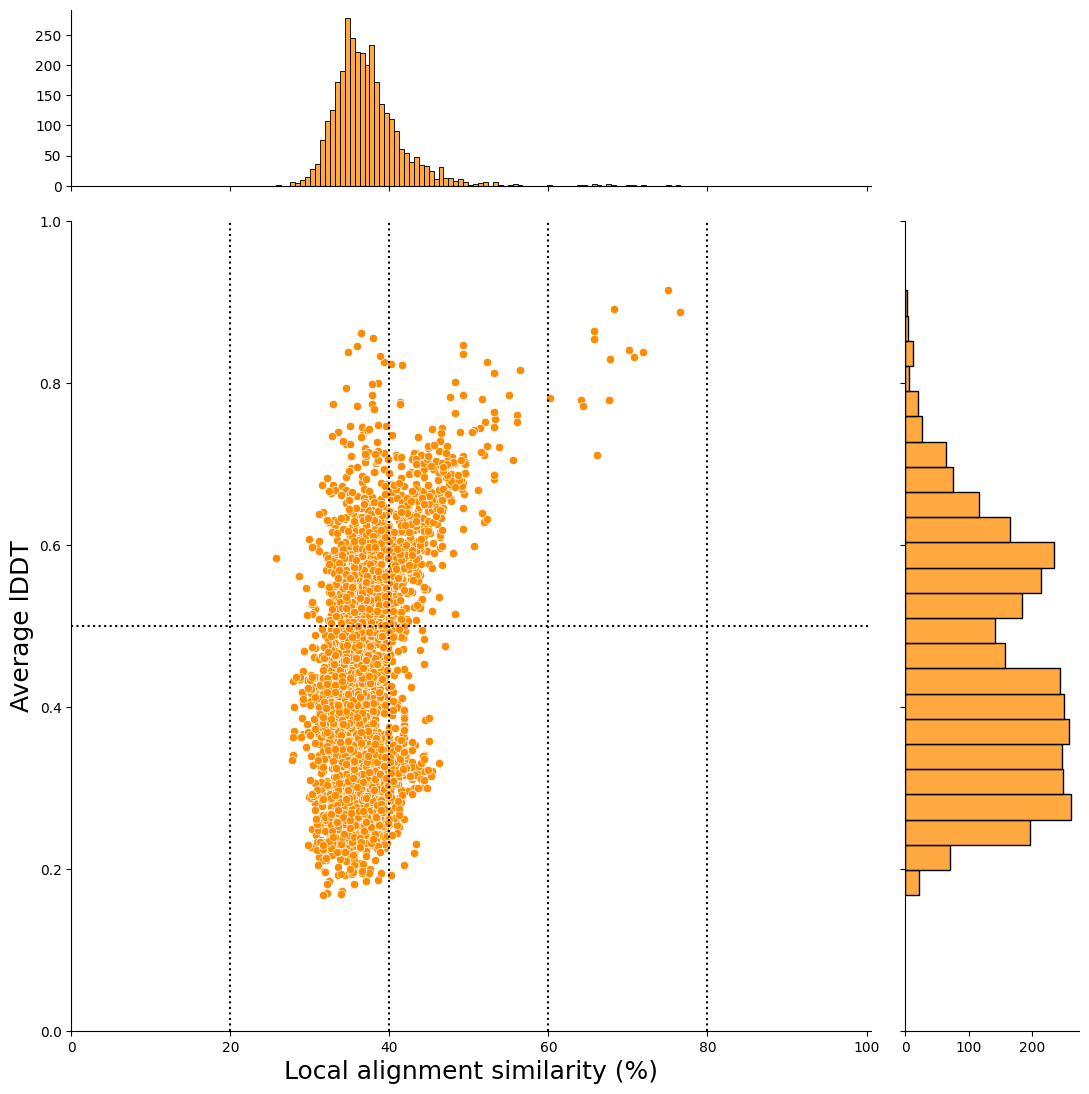

In [12]:
foldseek_filter_viz2 = join_foldseek.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz2,
    x="Similarity_percent_water", # local alignment similarity
    y="lddt",
    color="darkorange",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(0,100.5)
plt.ylim(0,1)
plt.xlabel("Local alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_water_lddt_all.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (6) Counting foldseek hits in Gene level

In [13]:
all_gene_list = pl.read_csv(
    query_gene_list_tsv_path,
    separator='\t'
).select(
    "From"
).unique()

hit_count = all_gene_list.join(
    join_foldseek,
    on="From",
    how="left",
    coalesce=True
).group_by("From", maintain_order=True).agg(
    (pl.col("foldseek hit").count().alias("target hit count (gene level vs uniprot accession)")),
    (pl.col("foldseek hit").is_null().all().alias("foldseek no hit"))
).sort(
    ["target hit count (gene level vs uniprot accession)"], descending=True
)

hit_count.write_csv(
    "foldseek_result_gene_level_hit_count_all.tsv",
    separator='\t'
)

display(hit_count)

From,target hit count (gene level vs uniprot accession),foldseek no hit
str,u32,bool
"""Zm00001eb360560""",300,false
"""Zm00001eb116750""",233,false
"""Zm00001eb374350""",229,false
"""Zm00001eb025900""",221,false
"""Zm00001eb305300""",209,false
…,…,…
"""Zm00001eb051760""",0,true
"""Zm00001eb180400""",0,true
"""Zm00001eb308520""",0,true


&nbsp;

&nbsp;

&nbsp;

# Caution:

- The filtering steps that are executed below can be changed freely.

&nbsp;

## (7) Filtering Condition1

- alignment coverage `>= 0.5`

In [14]:
condition1 = join_foldseek.filter(
        (pl.col("qcov") >= 0.5) &
        (pl.col("tcov") >= 0.5)
    ).sort(
        by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession
        descending=[False, False, False]
    )

condition1_rm = condition1.filter(
        (pl.col("qcov") < 0.5) |
        (pl.col("tcov") < 0.5)
    )

print(condition1.group_by(["From"], maintain_order=True).n_unique())
display(condition1)

shape: (52, 52)
┌────────────┬────────────┬────────────┬────────┬───┬────────────┬────────────┬───────────┬────────┐
│ From       ┆ UniProt    ┆ foldseek   ┆ evalue ┆ … ┆ Score_need ┆ Gap_penalt ┆ Extend_pe ┆ Matrix │
│ ---        ┆ Accession  ┆ hit        ┆ ---    ┆   ┆ le         ┆ y          ┆ nalty     ┆ ---    │
│ str        ┆ ---        ┆ ---        ┆ u32    ┆   ┆ ---        ┆ ---        ┆ ---       ┆ u32    │
│            ┆ u32        ┆ u32        ┆        ┆   ┆ u32        ┆ u32        ┆ u32       ┆        │
╞════════════╪════════════╪════════════╪════════╪═══╪════════════╪════════════╪═══════════╪════════╡
│ Zm00001eb0 ┆ 1          ┆ 11         ┆ 11     ┆ … ┆ 11         ┆ 1          ┆ 1         ┆ 1      │
│ 15640      ┆            ┆            ┆        ┆   ┆            ┆            ┆           ┆        │
│ Zm00001eb0 ┆ 1          ┆ 21         ┆ 21     ┆ … ┆ 21         ┆ 1          ┆ 1         ┆ 1      │
│ 16860      ┆            ┆            ┆        ┆   ┆            ┆         

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""Zm00001eb015640""","""A0A804LJK8""","""P0DN86""",0.2318,0.04,12,1.7,0.017,3,1,106,171,1,122,165,171,0.62,0.739,0.4376,0.2428,0.2501,0.3569,4.404,"""MGRAINKIVMAVELIKVLLMALVLTNITYH…","""MEMFQGLLLLLLLSMGG--T--WA--SKEP…",54,"""0.906,1.000,1.000,0.979,1.000,…",152,229,"""36/152""","""40/229""",23.7,17.5,33.6,25.3,"""59/152""","""122/229""",38.8,53.3,21.05,23.39,38.71,37.38,29.82,33.92,54.84,54.21,123.0,118.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb015640""","""A0A804LJK8""","""P0DN87""",0.2262,0.04,14,1.0,0.01,2,1,113,171,1,133,165,188,0.661,0.806,0.4677,0.2389,0.2459,0.3335,4.529,"""MGRAINKIVMAVELIKVLLMALVLTNITYH…","""MEMFQGLLLLLLLSMGG--T-W-A-S-REM…",56,"""0.906,1.000,1.000,0.979,1.000,…",152,229,"""35/152""","""39/229""",23.0,17.0,32.9,24.9,"""59/152""","""122/229""",38.8,53.3,20.47,22.81,37.63,36.45,29.24,33.33,53.76,53.27,108.0,104.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb015640""","""A0A804LJK8""","""P23510""",0.2524,0.057,11,0.6,0.006,1,1,121,171,30,131,183,157,0.708,0.557,0.54,0.2759,0.2607,0.4195,4.742,"""MGRAINKIVMAVELIKVLLMALVLTNITYH…","""VIQGLGLLLCFTYICLHFSAL-QV-SH--R…",65,"""0.594,0.850,0.818,0.958,0.942,…",161,236,"""31/161""","""35/236""",19.3,14.8,42.2,31.4,"""57/161""","""118/236""",35.4,50.0,16.94,19.13,29.81,29.66,37.16,40.44,65.38,62.71,138.0,123.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb015640""","""A0A804LJK8""","""P41271""",0.2189,0.04,22,2.8,0.028,4,8,99,171,25,138,181,142,0.538,0.63,0.3374,0.2433,0.233,0.3801,5.046,"""IVMAVELIKVLLMALVLTNITYHLILIVTV…","""LALFPDK--S-AW--CE--AK--NI--TQI…",60,"""0.328,0.309,0.338,0.431,0.431,…",162,236,"""30/162""","""32/236""",18.5,13.6,34.0,25.4,"""51/162""","""120/236""",31.5,50.8,16.57,17.68,27.03,27.59,30.39,33.15,49.55,51.72,97.0,96.5,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb015640""","""A0A804LJK8""","""Q13103""",0.2134,0.045,14,1.7,0.017,3,1,109,171,12,129,211,167,0.637,0.559,0.4557,0.2478,0.2084,0.3522,4.622,"""MGRAINKIVMAVELIKVLLMALVLTNITYH…","""MKILIMFALGMNYWSC-S-G-F-P--VY-D…",57,"""0.562,0.825,0.841,0.938,0.846,…",208,247,"""33/208""","""34/247""",15.9,13.8,34.1,29.6,"""79/208""","""112/247""",38.0,45.3,15.64,16.11,25.58,25.19,33.65,34.6,55.04,54.07,95.0,90.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zm00001eb423300""","""K7TTJ0""","""Q9GZP4""",0.2463,0.051,16,1.3,0.013,4,9,215,217,10,173,211,298,0.954,0.777,0.4132,0.2566,0.2628,0.3247,4.419,"""LALAC---------------LAVMAAALAD…","""GGCRCAAEREEPPEQRGLAY----------…",69,"""0.375,0.375,0.438,0.375,0.312,…",205,290,"""42/205""","""46/290""",20.5,15.9,37.1,27.2,"""75/205""","""152/290""",36.6,52.4,19.35,21.2,32.31,33.33,35.02,36.41,58.46,57.25,167.5,160.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb423300""","""K7TTJ0""","""Q9H426""",0.2467,0.063,24,3.2,0.032,9,6,217,217,34,204,269,281,0.977,0.636,0.4259,0.2891,0.2454,0.3414,6.038,"""AAALALACLAVMAAALADGALLP------W…","""DSRRLKGAIQRSTETGLAVEM-PSRTLRQ-…",93,"""0.469,0.562,0.719,0.844,0.938,…",199,325,"""42/199""","""47/325""",21.1,14.5,40.2,26.8,"""56/199""","""164/325""",28.1,50.5,15.61,17.47,29.37,29.19,29.74,32.34,55.94,54.04,1

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (8) Filtering Condition2

- If there are hits with the same target for the same gene-derived UniProt ID, the one with the highest qcov is selected, and if the qcov is the same, the one with the highest lDDT is selected.
- **Note that in this study, we leave the states with the same foldseek hit even if the rice genes are different.**

In [15]:
condition2 = condition1.sort(
    by=["qcov", "lddt"],
    descending=[True, True]
).group_by(
    ["From", "foldseek hit"],
    maintain_order=True
).agg(
    pl.all().first()
).sort(
    by=["From", "UniProt Accession", "foldseek hit"],
    descending=[False, False, False]
).select(
    "From",
    "UniProt Accession",
    "foldseek hit",
    "evalue",
    "prob",
    "gapopen",
    "pident",
    "fident",
    "nident",
    "qstart",
    "qend",
    "qlen",
    "tstart",
    "tend",
    "tlen",
    "alnlen",
    "qcov",
    "tcov",
    "lddt",
    "qtmscore",
    "ttmscore",
    "alntmscore",
    "rmsd",
    "mismatch",
    "Align_Length_water",
    "Align_Length_needle",
    "Identity_water",
    "Identity_needle",
    "Identity_percent_water",
    "Identity_percent_needle",
    "Similarity_percent_water",
    "Similarity_percent_needle",
    "Shortest_Identity_water",
    "Shortest_Identity_needle",
    "Longest_Identity_water",
    "Longest_Identity_needle",
    "Shortest_Similarity_water",
    "Shortest_Similarity_needle",
    "Longest_Similarity_water",
    "Longest_Similarity_needle",
    "Gaps_water",
    "Gaps_percent_water",
    "Gaps_needle",
    "Gaps_percent_needle",
    "Score_water",
    "Score_needle",
    "Gap_penalty",
    "Extend_penalty",
    "Matrix"
)

display(condition2)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,mismatch,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,str
"""Zm00001eb015640""","""A0A804LJK8""","""P0DN86""",0.2318,0.04,12,1.7,0.017,3,1,106,171,1,122,165,171,0.62,0.739,0.4376,0.2428,0.2501,0.3569,4.404,54,152,229,"""36/152""","""40/229""",23.7,17.5,33.6,25.3,21.05,23.39,38.71,37.38,29.82,33.92,54.84,54.21,"""59/152""",38.8,"""122/229""",53.3,123.0,118.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb015640""","""A0A804LJK8""","""P0DN87""",0.2262,0.04,14,1.0,0.01,2,1,113,171,1,133,165,188,0.661,0.806,0.4677,0.2389,0.2459,0.3335,4.529,56,152,229,"""35/152""","""39/229""",23.0,17.0,32.9,24.9,20.47,22.81,37.63,36.45,29.24,33.33,53.76,53.27,"""59/152""",38.8,"""122/229""",53.3,108.0,104.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb015640""","""A0A804LJK8""","""P23510""",0.2524,0.057,11,0.6,0.006,1,1,121,171,30,131,183,157,0.708,0.557,0.54,0.2759,0.2607,0.4195,4.742,65,161,236,"""31/161""","""35/236""",19.3,14.8,42.2,31.4,16.94,19.13,29.81,29.66,37.16,40.44,65.38,62.71,"""57/161""",35.4,"""118/236""",50.0,138.0,123.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb015640""","""A0A804LJK8""","""P41271""",0.2189,0.04,22,2.8,0.028,4,8,99,171,25,138,181,142,0.538,0.63,0.3374,0.2433,0.233,0.3801,5.046,60,162,236,"""30/162""","""32/236""",18.5,13.6,34.0,25.4,16.57,17.68,27.03,27.59,30.39,33.15,49.55,51.72,"""51/162""",31.5,"""120/236""",50.8,97.0,96.5,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb015640""","""A0A804LJK8""","""Q13103""",0.2134,0.045,14,1.7,0.017,3,1,109,171,12,129,211,167,0.637,0.559,0.4557,0.2478,0.2084,0.3522,4.622,57,208,247,"""33/208""","""34/247""",15.9,13.8,34.1,29.6,15.64,16.11,25.58,25.19,33.65,34.6,55.04,54.07,"""79/208""",38.0,"""112/247""",45.3,95.0,90.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zm00001eb423300""","""K7TTJ0""","""Q9GZP4""",0.2463,0.051,16,1.3,0.013,4,9,215,217,10,173,211,298,0.954,0.777,0.4132,0.2566,0.2628,0.3247,4.419,69,205,290,"""42/205""","""46/290""",20.5,15.9,37.1,27.2,19.35,21.2,32.31,33.33,35.02,36.41,58.46,57.25,"""75/205""",36.6,"""152/290""",52.4,167.5,160.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb423300""","""K7TTJ0""","""Q9H426""",0.2467,0.063,24,3.2,0.032,9,6,217,217,34,204,269,281,0.977,0.636,0.4259,0.2891,0.2454,0.3414,6.038,93,199,325,"""42/199""","""47/325""",21.1,14.5,40.2,26.8,15.61,17.47,29.37,29.19,29.74,32.34,55.94,54.04,"""56/199""",28.1,"""164/325""",50.5,137.0,132.5,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb423300""","""K7TTJ0""","""Q9NQM4""",0.2137,0.034,13,2.2,0.022,6,45,217,217,28,202,214,271,0.797,0.818,0.3466,0.2298,0.2323,0.2725,5.395,71,226,295,"""38/226""","""39/295""",16.8,13.2,32.3,25.1,17.51,17.97,28.79,28.68,33.64,34.1,55.3,54.41,"""94/226""",41.6,"""159/295""",53.9,138.5,134.5,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (9) Filtering Condition3

- Select hits that can be converted to Ensembl gene id and HGNC Gene nomenclature with TogoID API
- https://togoid.dbcls.jp/

In [16]:
togoid_convert = pl.read_csv(
    togoid_convert_tsv_path,
    separator='\t'
).rename(
    {
        "uniprot_id" : "foldseek hit"
    }
).filter(
    pl.col("ensembl_gene_id").is_not_null() &
    pl.col("hgnc_symbol_id").is_not_null() # add HGNC Gene nomenclature information filtering condition
).sort(
    by=["foldseek hit"],
    descending=[False]
)

display(togoid_convert)

foldseek hit,ensembl_protein_id,ensembl_transcript_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id
str,str,str,str,i64,str
"""A0A087WXM9""","""ENSP00000488568""","""ENST00000442687""","""ENSG00000239642""",51253,"""MEIKIN"""
"""A0A1W2PR48""","""ENSP00000492311""","""ENST00000561754""","""ENSG00000260734""",53648,"""TLE7"""
"""A0A1W2PR95""","""ENSP00000492384""","""ENST00000583666""","""ENSG00000266826""",43611,"""IGBP1C"""
"""A0A286YEU6""","""ENSP00000492889""","""ENST00000572493""","""ENSG00000180042""",8226,"""OR1R1"""
"""A0A3B3IT33""","""ENSP00000497050""","""ENST00000534741""","""ENSG00000220948""",43972,"""TRIM51G"""
…,…,…,…,…,…
"""Q9Y6S9""","""ENSP00000450567""","""ENST00000557413""","""ENSG00000198208""",20222,"""RPS6KL1"""
"""Q9Y6W6""","""ENSP00000355866""","""ENST00000366899""","""ENSG00000143507""",3065,"""DUSP10"""
"""Q9Y6W8""","""ENSP00000319476""","""ENST00000316386""","""ENSG00000163600""",5351,"""ICOS"""


In [17]:
condition3 = condition2.join(
    togoid_convert,
    on="foldseek hit",
    how="left",
    coalesce=True
).drop(
    [
        "ensembl_transcript_id",
        "hgnc_id"
    ]
).filter( 
    pl.col("ensembl_gene_id").is_not_null() &
    pl.col("hgnc_symbol_id").is_not_null() # add HGNC Gene nomenclature information filtering condition
).select(
    [
        "From",
        "UniProt Accession",
        "foldseek hit",
        "ensembl_protein_id",
        "ensembl_gene_id",
        "hgnc_symbol_id",
        "evalue",
        "prob",
        "gapopen",
        "pident",
        "fident",
        "nident",
        "qstart",
        "qend",
        "qlen",
        "tstart",
        "tend",
        "tlen",
        "alnlen",
        "mismatch",
        "qcov",
        "tcov",
        "rmsd",
        "lddt",
        "qtmscore",
        "ttmscore",
        "alntmscore",
        "Align_Length_water",
        "Align_Length_needle",
        "Identity_water",
        "Identity_percent_water",
        "Identity_percent_needle",
        "Similarity_percent_water",
        "Similarity_percent_needle",
        "Shortest_Identity_water",
        "Shortest_Identity_needle",
        "Longest_Identity_water",
        "Longest_Identity_needle",
        "Shortest_Similarity_water",
        "Shortest_Similarity_needle",
        "Longest_Similarity_water",
        "Longest_Similarity_needle",
        "Gaps_water",
        "Gaps_percent_water",
        "Gaps_needle",
        "Gaps_percent_needle",
        "Score_water",
        "Score_needle",
        "Gap_penalty",
        "Extend_penalty",
        "Matrix"
    ]
).sort(
    by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession (change order)
    descending=[False, False, False]
)

condition3.write_csv(
    "foldseek_result_join_alignment_result_filter.tsv",
    separator='\t'
)

display(condition3)

From,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,Align_Length_water,Align_Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,str
"""Zm00001eb015640""","""A0A804LJK8""","""P0DN86""","""ENSP00000301408""","""ENSG00000189052""","""CGB5""",0.2318,0.04,12,1.7,0.017,3,1,106,171,1,122,165,171,54,0.62,0.739,4.404,0.4376,0.2428,0.2501,0.3569,152,229,"""36/152""",23.7,17.5,33.6,25.3,21.05,23.39,38.71,37.38,29.82,33.92,54.84,54.21,"""59/152""",38.8,"""122/229""",53.3,123.0,118.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb015640""","""A0A804LJK8""","""P0DN86""","""ENSP00000349954""","""ENSG00000104827""","""CGB3""",0.2318,0.04,12,1.7,0.017,3,1,106,171,1,122,165,171,54,0.62,0.739,4.404,0.4376,0.2428,0.2501,0.3569,152,229,"""36/152""",23.7,17.5,33.6,25.3,21.05,23.39,38.71,37.38,29.82,33.92,54.84,54.21,"""59/152""",38.8,"""122/229""",53.3,123.0,118.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb015640""","""A0A804LJK8""","""P0DN86""","""ENSP00000403649""","""ENSG00000213030""","""CGB8""",0.2318,0.04,12,1.7,0.017,3,1,106,171,1,122,165,171,54,0.62,0.739,4.404,0.4376,0.2428,0.2501,0.3569,152,229,"""36/152""",23.7,17.5,33.6,25.3,21.05,23.39,38.71,37.38,29.82,33.92,54.84,54.21,"""59/152""",38.8,"""122/229""",53.3,123.0,118.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb015640""","""A0A804LJK8""","""P0DN87""","""ENSP00000469076""","""ENSG00000196337""","""CGB7""",0.2262,0.04,14,1.0,0.01,2,1,113,171,1,133,165,188,56,0.661,0.806,4.529,0.4677,0.2389,0.2459,0.3335,152,229,"""35/152""",23.0,17.0,32.9,24.9,20.47,22.81,37.63,36.45,29.24,33.33,53.76,53.27,"""59/152""",38.8,"""122/229""",53.3,108.0,104.0,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb015640""","""A0A804LJK8""","""P0DN87""","""ENSP00000470813""","""ENSG00000196337""","""CGB7""",0.2262,0.04,14,1.0,0.01,2,1,113,171,1,133,165,188,56,0.661,0.806,4.529,0.4677,0.2389,0.2459,0.3335,152,229,"""35/152""",23.0,17.0,32.9,24.9,20.47,22.81,37.63,36.45,29.24,33.33,53.76,53.27,"""59/152""",38.8,"""122/229""",53.3,108.0,104.0,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zm00001eb423300""","""K7TTJ0""","""Q9NQM4""","""ENSP00000361531""","""ENSG00000080572""","""DNAAF6""",0.2137,0.034,13,2.2,0.022,6,45,217,217,28,202,214,271,71,0.797,0.818,5.395,0.3466,0.2298,0.2323,0.2725,226,295,"""38/226""",16.8,13.2,32.3,25.1,17.51,17.97,28.79,28.68,33.64,34.1,55.3,54.41,"""94/226""",41.6,"""159/295""",53.9,138.5,134.5,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb423300""","""K7TTJ0""","""Q9NQM4""","""ENSP00000441930""","""ENSG00000080572""","""DNAAF6""",0.2137,0.034,13,2.2,0.022,6,45,217,217,28,202,214,271,71,0.797,0.818,5.395,0.3466,0.2298,0.2323,0.2725,226,295,"""38/226""",16.8,13.2,32.3,25.1,17.51,17.97,28.79,28.68,33.64,34.1,55.3,54.41,"""94/226""",41.6,"""159/295""",53.9,138.5,134.5,10.0,0.5,"""EBLOSUM30"""
"""Zm00001eb423300""","""K7TTJ0""","""Q9UBY9""","""ENSP00000310111""","""ENSG00000173641""","""HSPB7""",0.4092,0.15,6,20.0,0.2,23,71,180,217,63,159,170,115,69,0.507,0.571,3.221,0.6511,0.3722,0.466,0.7845,244,246,"""51/244""",20.9,20.7,37.7,37.4,23.5,23.5,36.17,36.17,42.4,42.4,65.25,65.25,"""103/244""",42.2,"""105/246""",42.7,168.5,168.5,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;


In [18]:
foldseek_filter_viz = condition3.select(
    "From",
    "UniProt Accession",
    "foldseek hit",
    "qcov",
    "tcov",
    "rmsd",
    "lddt",
    "Identity_percent_needle",
    "Identity_percent_water",
    "Similarity_percent_needle",
    "Similarity_percent_water"
).unique(
    subset=["From", "UniProt Accession", "foldseek hit"]
).sort(
    by=["From"],
    descending=[False]
)

display(foldseek_filter_viz)

From,UniProt Accession,foldseek hit,qcov,tcov,rmsd,lddt,Identity_percent_needle,Identity_percent_water,Similarity_percent_needle,Similarity_percent_water
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""Zm00001eb015640""","""A0A804LJK8""","""Q9HBJ0""",0.889,0.675,4.312,0.4685,13.5,15.3,36.1,41.1
"""Zm00001eb015640""","""A0A804LJK8""","""Q8N5L8""",0.556,0.847,2.902,0.772,16.2,27.5,21.8,35.9
"""Zm00001eb015640""","""A0A804LJK8""","""Q13103""",0.637,0.559,4.622,0.4557,13.8,15.9,29.6,34.1
"""Zm00001eb015640""","""A0A804LJK8""","""P23510""",0.708,0.557,4.742,0.54,14.8,19.3,31.4,42.2
"""Zm00001eb015640""","""A0A804LJK8""","""Q7Z5A9""",0.62,0.925,4.249,0.5365,12.1,21.5,20.8,36.9
…,…,…,…,…,…,…,…,…,…,…
"""Zm00001eb423300""","""K7TTJ0""","""O95156""",0.525,0.545,5.321,0.3526,12.8,21.6,23.2,38.7
"""Zm00001eb423300""","""K7TTJ0""","""P58417""",0.507,0.779,5.287,0.367,13.8,18.4,27.7,36.9
"""Zm00001eb423300""","""K7TTJ0""","""Q9NQM4""",0.797,0.818,5.395,0.3466,13.2,16.8,25.1,32.3


<Figure size 4000x4000 with 0 Axes>

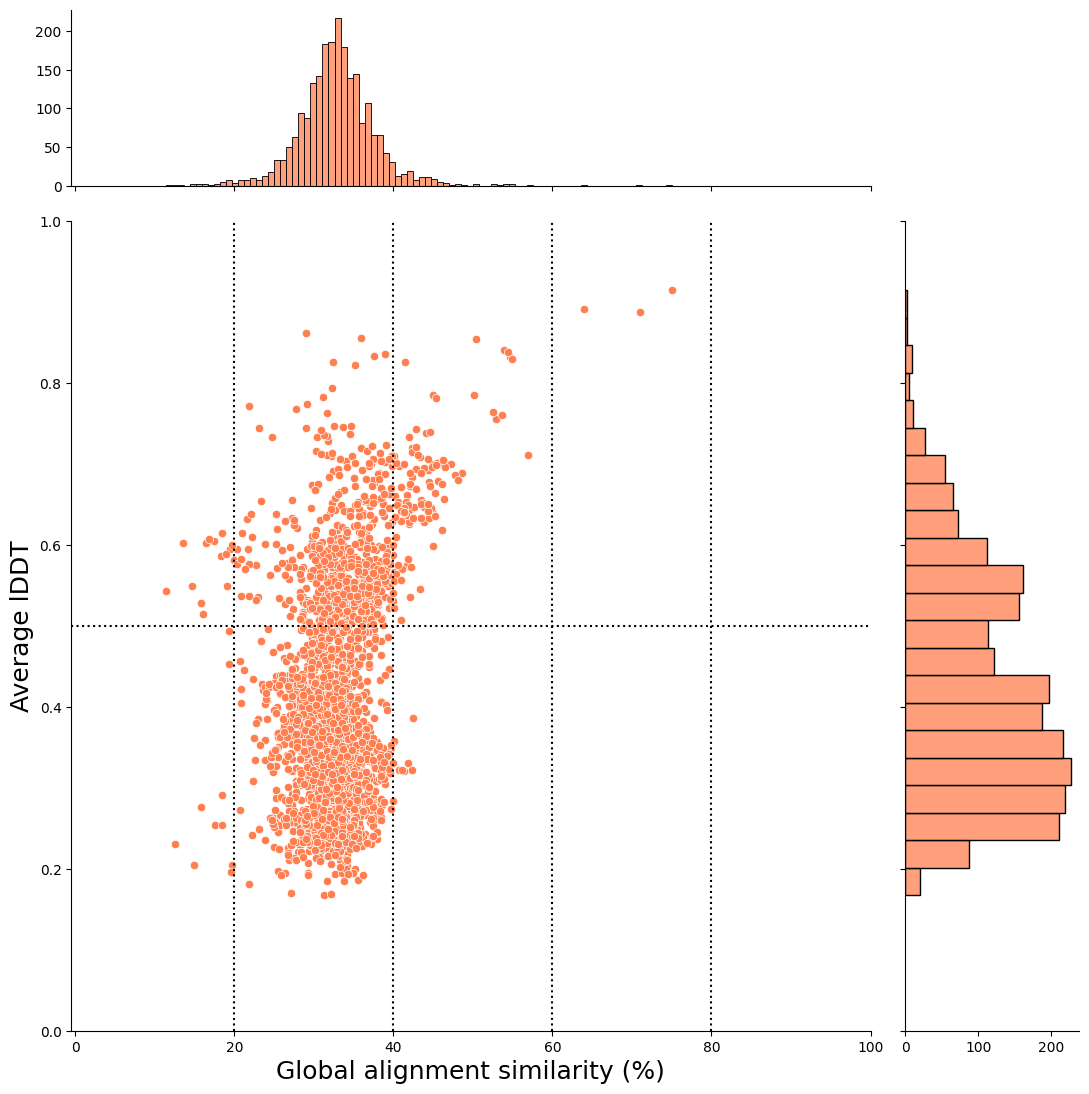

In [19]:
foldseek_filter_viz_pd = foldseek_filter_viz.to_pandas()

plt.figure(figsize=(8, 8), dpi=500)

sns.jointplot(
    data=foldseek_filter_viz_pd,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_needle_lddt_filter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 4000x4000 with 0 Axes>

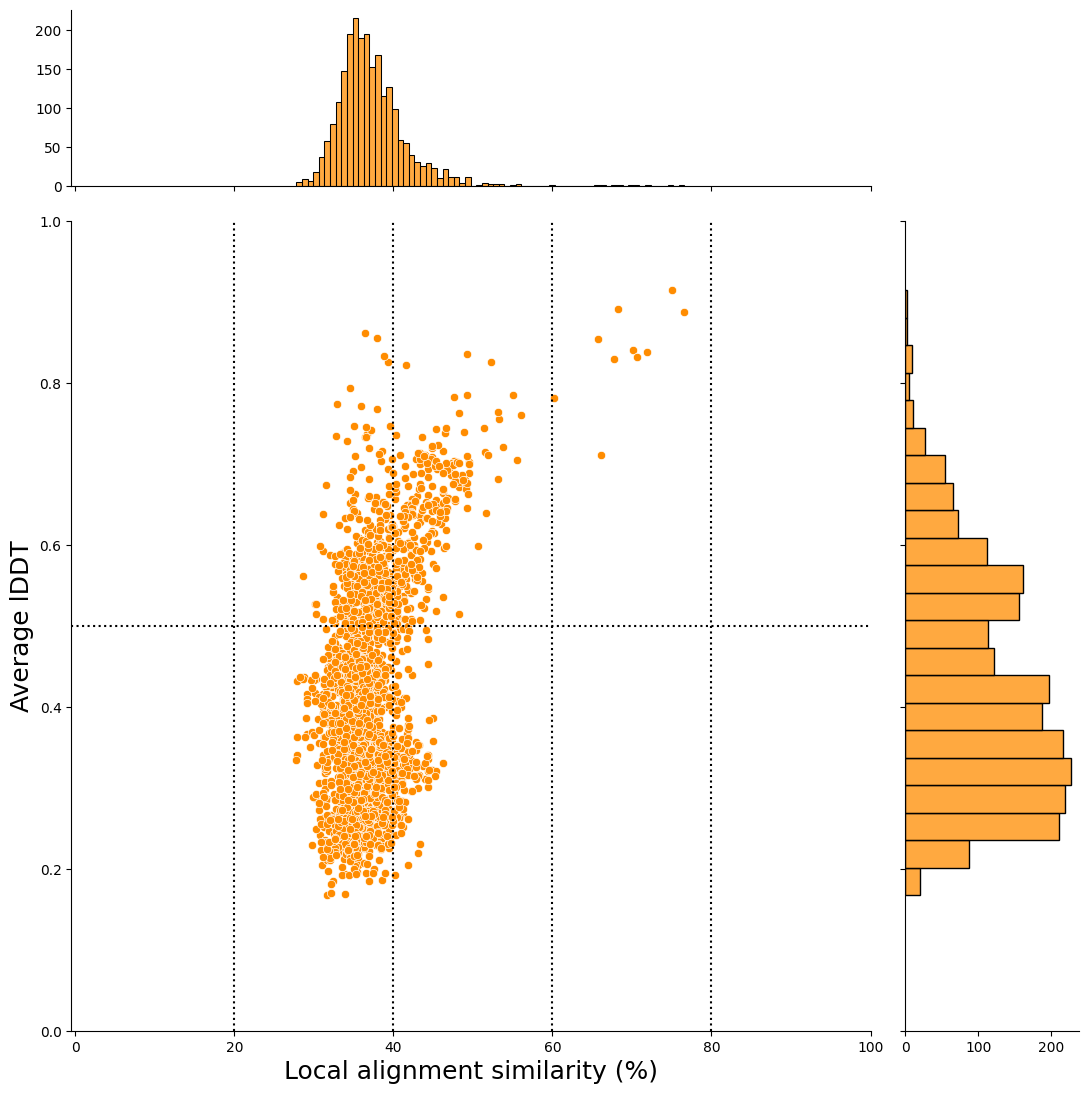

In [20]:
foldseek_filter_viz_pd = foldseek_filter_viz.to_pandas()

plt.figure(figsize=(8, 8), dpi=500)

sns.jointplot(
    data=foldseek_filter_viz_pd,
    x="Similarity_percent_water",
    y="lddt",
    color="darkorange",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100)
plt.ylim(0,1)
plt.xlabel("Local alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_water_lddt_filter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;
